# C01 · Golf putting: when physics beats curve fitting

| | |
|---|---|
| **Difficulty** | ★★☆☆☆ |
| **Time** | 2-3 hours |
| **Data** | Berry (1996) pro putting data; Broadie's modern PGA data |
| **Skills** | Binomial likelihoods · building a likelihood from a mechanistic model · prior predictive checks · LOO model comparison · diagnosing a sampler that refuses to mix · model expansion |

## The brief

A golf analytics company wants a model for the probability that a professional sinks a putt
as a function of distance. It will feed a "strokes gained" product, so it has to
**extrapolate sensibly** and its parameters should **mean something** to a coach.

You get two datasets: a small classic one (19 distances, ~5,600 putts) and a modern one
with 30x more putts. A model that looks great on the first will break on the second.
Your job is to find out why and fix it.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", sigma_angle_deg=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

from pymc_challenges import Hints, data

RANDOM_SEED = 1996
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C01")
h.tasks()

**C01 - Golf putting: when physics beats curve fitting**

- `task1` - Logistic regression baseline (3 hints, 2 check(s))
- `task2` - A mechanistic angle model (3 hints, 1 check(s))
- `task3` - LOO comparison (3 hints)
- `task4` - New data breaks the model (3 hints)
- `task5` - Distance control and a sampler that will not mix (3 hints, 2 check(s))
- `task6` - Answer the business question (3 hints, 1 check(s))

## The data

`x` is the distance to the hole in feet, `n` the number of putts attempted from that
distance and `y` how many went in.

In [2]:
data.describe("golf")
golf = data.load("golf")
golf.head()

golf: Putts attempted and made by distance (feet), 19 distances.
  source: Berry (1996), professional golf putting; used in Gelman & Nolan (2002).
  url:    https://raw.githubusercontent.com/stan-dev/example-models/master/knitr/golf/golf_data.txt


,x,n,y
0,2,1443,1346
1,3,694,577
2,4,455,337
3,5,353,208
4,6,272,149


Two physical constants you will need later (both in **feet**, like `x`):

In [3]:
BALL_RADIUS = (1.68 / 2) / 12
HOLE_RADIUS = (4.25 / 2) / 12

## Task 0 · Look at the data

Plot the empirical success rate against distance **with an uncertainty interval for each
point**. Which distances are measured precisely, and which are not?

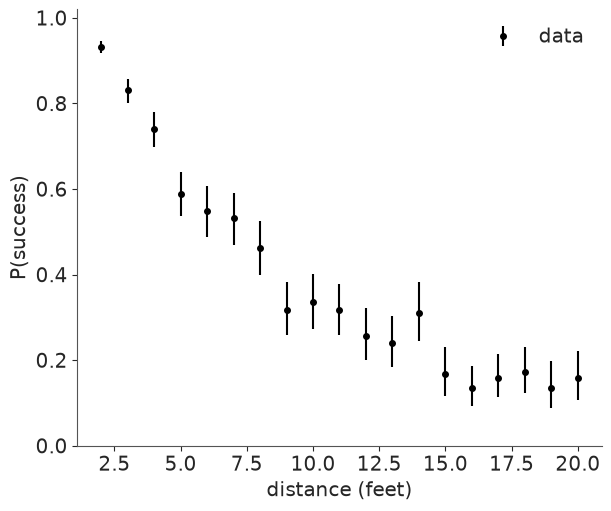

In [4]:
def plot_data(df, ax=None, label="data", color="k"):
    """Success rate with a 95% Jeffreys interval per distance."""
    ax = ax or plt.gca()
    rate = df.y / df.n
    lo, hi = stats.beta.interval(0.95, df.y + 0.5, df.n - df.y + 0.5)
    ax.errorbar(df.x, rate, yerr=[rate - lo, hi - rate], fmt="o", ms=4, color=color, label=label)
    ax.set(xlabel="distance (feet)", ylabel="P(success)", ylim=(0, 1.02))
    return ax


plot_data(golf)
plt.legend();

Short putts are attempted far more often, so the left of the curve is pinned down tightly
while the right is noisy. Whatever model we choose will mostly be judged on short putts.

## Task 1 · The default: logistic regression

Fit the model every analyst reaches for first:

$$y_i \sim \text{Binomial}(n_i, p_i), \qquad \text{logit}(p_i) = a + b\,x_i$$

**Deliver**
1. Priors you can defend. *Show* with a prior predictive plot that they imply plausible
   curves (no 50% success at 0 feet, no cliff edges).
2. A fitted model with clean diagnostics (`r_hat`, ESS, divergences).
3. A plot of the posterior success curve with a credible band on top of the data.
   Where does the fit fail, and in which direction?

### Solution

`x` runs from 2 to 20 feet, so a slope of ±0.5 per foot already moves the log-odds by 9
across the range. `Normal(0, 0.5)` on `b` and `Normal(0, 1.5)` on `a` are weakly
informative on this scale. The prior predictive plot is how we check that claim instead of
just asserting it.

Sampling: [a, b, y]


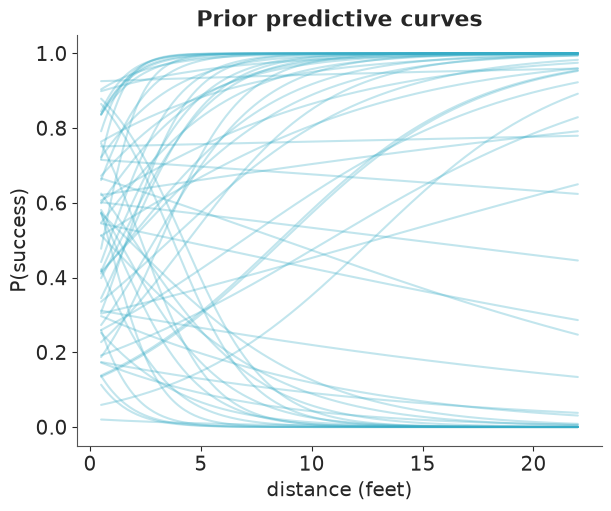

In [5]:
x_grid = np.linspace(0.5, 22, 200)

with pm.Model() as logit_model:
    a = pm.Normal("a", 0, 1.5)
    b = pm.Normal("b", 0, 0.5)
    pm.Binomial("y", n=golf.n.values, logit_p=a + b * golf.x.values, observed=golf.y.values)
    logit_prior = pm.sample_prior_predictive(200, random_seed=RANDOM_SEED)

prior = az.extract(logit_prior, group="prior", var_names=["a", "b"])
curves = 1 / (1 + np.exp(-(prior["a"].values[:, None] + prior["b"].values[:, None] * x_grid)))
plt.plot(x_grid, curves[:60].T, color="C0", alpha=0.3)
plt.gca().set(xlabel="distance (feet)", ylabel="P(success)", title="Prior predictive curves");

The prior allows rising curves, which we *know* are wrong. You could encode that
(`b = -HalfNormal`), but with this much data it will not matter - the point of the check is
that nothing absurd, like a step function, dominates.

In [6]:
with logit_model:
    logit_idata = pm.sample(random_seed=RANDOM_SEED)

az.summary(logit_idata)

NUTS[nutpie]: [a, b]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,2.228,0.06,2.1,2.3,970,1284,1.00,0.0019,0.0012
b,-0.2554,0.0068,-0.27,-0.24,970,1280,1.00,0.00022,0.00014


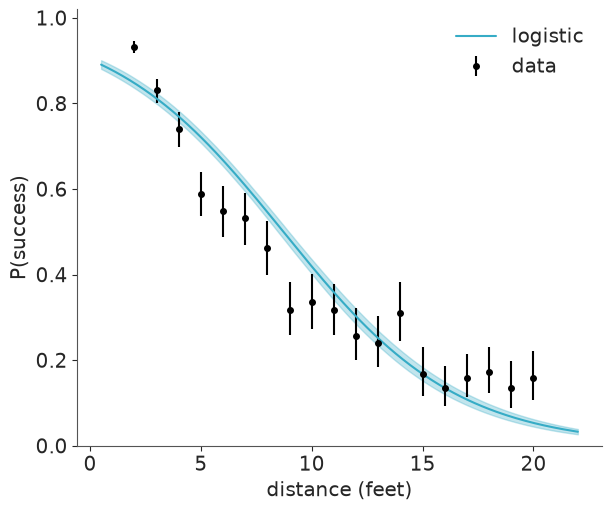

In [7]:
def plot_curve(curves, ax=None, color="C0", label=None):
    """Posterior mean and 94% band of an array of curves with shape (draws, len(x_grid))."""
    ax = ax or plt.gca()
    lo, hi = np.quantile(curves, [0.03, 0.97], axis=0)
    ax.fill_between(x_grid, lo, hi, color=color, alpha=0.3)
    ax.plot(x_grid, curves.mean(axis=0), color=color, label=label)


post = az.extract(logit_idata, var_names=["a", "b"])
logit_curves = 1 / (1 + np.exp(-(post["a"].values[:, None] + post["b"].values[:, None] * x_grid)))

plot_data(golf)
plot_curve(logit_curves, label="logistic")
plt.legend();

In [8]:
assert h.check("task1", a=logit_idata.posterior["a"].mean(), b=logit_idata.posterior["b"].mean())

- PASS `a` = 2.228 is consistent with the reference solution.
- PASS `b` = -0.2554 is consistent with the reference solution.

The band is tiny - the model is *confident* - and yet it misses systematically: too low
for short putts, too high in the middle, and it goes to `p = 0.9` rather than 1 at zero
distance. A narrow posterior is a statement about the parameters *given the model*, never
evidence that the model is right.

## Task 2 · Think like a golfer

A putt goes in if the ball's centre passes over the hole. Suppose the golfer aims at the
centre but the launch **angle** is off by a random error $\theta \sim \text{Normal}(0, \sigma)$.

**Deliver**
1. Derive $p(x)$ from the geometry (constants `BALL_RADIUS`, `HOLE_RADIUS` are above) and
   write it down in a markdown cell. It has **one** free parameter.
2. Implement it in PyMC and fit it. Report $\sigma$ in **degrees**.
3. Overlay its posterior curve on the logistic fit. One parameter versus two - which wins?

### Solution

The ball drops if the angle error is smaller than the threshold angle
$\theta_0 = \arcsin\!\big((R - r)/x\big)$, where $R$ is the hole radius and $r$ the ball
radius. With $\theta \sim \text{Normal}(0, \sigma)$:

$$p(x) = P(|\theta| < \theta_0) = 2\,\Phi\!\left(\frac{\arcsin((R-r)/x)}{\sigma}\right) - 1$$

$\Phi$ is `pm.math.invprobit`. For the prior, a pro is unlikely to be off by more than a few
degrees: `HalfNormal(0.1)` radians (about 5.7°) is generous.

In [9]:
def p_angle(x, sigma_angle, xp=pm.math):
    """P(angle is good enough). Works on PyTensor variables (xp=pm.math) or NumPy arrays (xp=np)."""
    Phi = pm.math.invprobit if xp is pm.math else stats.norm.cdf
    return 2 * Phi(xp.arcsin((HOLE_RADIUS - BALL_RADIUS) / x) / sigma_angle) - 1


def fit_angle_model(df):
    with pm.Model() as model:
        sigma_angle = pm.HalfNormal("sigma_angle", 0.1)
        pm.Deterministic("sigma_angle_deg", sigma_angle * 180 / np.pi)
        pm.Binomial("y", n=df.n.values, p=p_angle(df.x.values, sigma_angle), observed=df.y.values)
        idata = pm.sample(random_seed=RANDOM_SEED)
    return model, idata


angle_model, angle_idata = fit_angle_model(golf)
az.summary(angle_idata)

NUTS[nutpie]: [sigma_angle]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle,0.02665,0.00039,0.026,0.027,1901,2583,1.00,9e-06,5.7e-06
sigma_angle_deg,1.527,0.0225,1.5,1.6,1901,2583,1.00,0.00052,0.00032


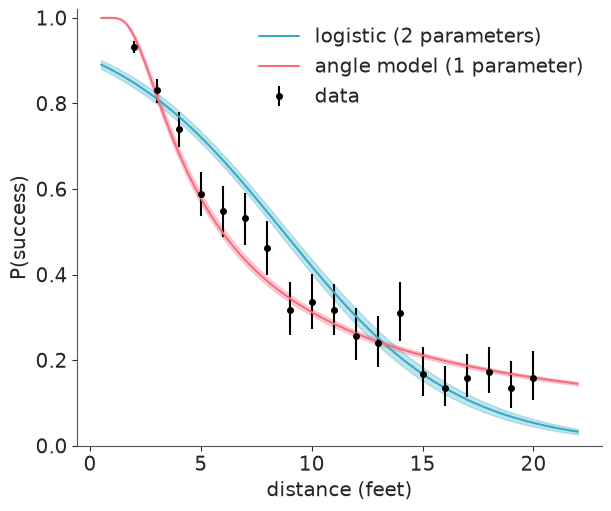

In [10]:
sigma_draws = az.extract(angle_idata, var_names="sigma_angle").values
angle_curves = p_angle(x_grid, sigma_draws[:, None], xp=np)

plot_data(golf)
plot_curve(logit_curves, color="C0", label="logistic (2 parameters)")
plot_curve(angle_curves, color="C1", label="angle model (1 parameter)")
plt.legend();

In [11]:
assert h.check("task2", sigma_angle_deg=angle_idata.posterior["sigma_angle_deg"].mean())

- PASS `sigma_angle_deg` = 1.527 is consistent with the reference solution.

One interpretable parameter - pros are off by about **1.5 degrees** - beats the
two-parameter curve fit everywhere, *and* it behaves correctly at the boundaries
($p \to 1$ as $x \to 0$).

## Task 3 · Make the comparison quantitative

Compare the two models with PSIS-LOO.

**Deliver** the `az.compare` table and two sentences: what does it say, and how far do you
trust it here? (Look at the warnings - there are only 19 "observations".)

In [12]:
with logit_model:
    pm.compute_log_likelihood(logit_idata)
with angle_model:
    pm.compute_log_likelihood(angle_idata)

az.compare({"logistic": logit_idata, "angle": angle_idata})

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
angle,0,0.0,0.0,NaN,,1 k̂ > 0.70,8.4,-90.0,14.0,0.86
logistic,1,-100.0,52.0,0.99,N < 100,2 k̂ > 0.70,40.9,-200.0,63.0,0.14


LOO strongly prefers the angle model, agreeing with the plot. But treat the numbers with
suspicion: each "observation" is a binomial count of hundreds of putts, so leaving one out
changes the posterior a lot and the Pareto-$k$ diagnostics complain. When LOO's importance
sampling is unreliable, the honest options are exact refits (`az.reloo`, cheap with 19
points) or, as here, to lean on posterior predictive checks where the verdict is obvious.

## Task 4 · New data breaks the model

Mark Broadie collected far more putts, out to 75 feet.

**Deliver**
1. Fit your angle model to `golf_new`, unchanged. Plot fit against data, and plot the
   **residuals** (observed rate − posterior mean). What is the pattern?
2. A one-paragraph hypothesis: what real-world mechanism is the model missing?

In [13]:
data.describe("golf_new")
golf_new = data.load("golf_new")
golf_new.tail()

golf_new: Putts attempted and made by distance (feet), 31 distances, far more putts.
  source: Mark Broadie's modern PGA putting data, via Gelman's golf case study.
  url:    https://raw.githubusercontent.com/stan-dev/example-models/master/knitr/golf/golf_data_new.txt


,x,n,y
26,52.36,8708,231
27,57.25,8878,204
28,63.23,5492,103
29,69.18,3087,35
30,75.19,1742,24


NUTS[nutpie]: [sigma_angle]


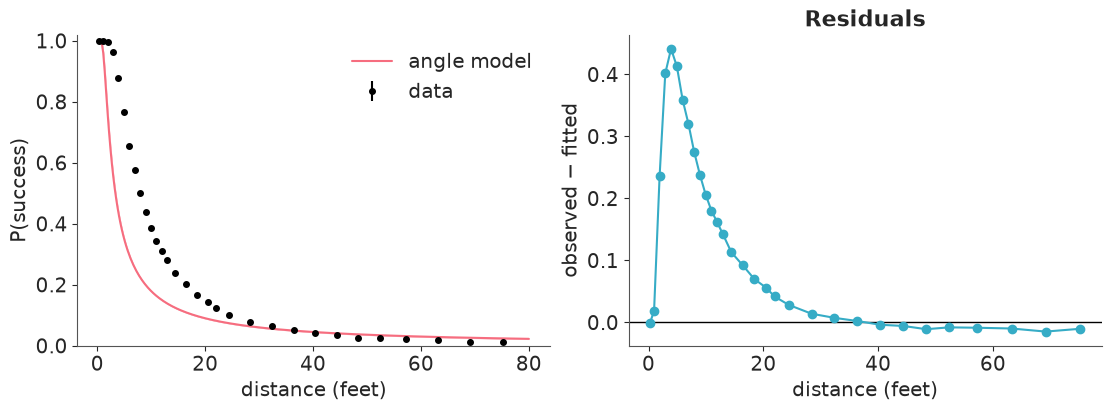

In [14]:
x_grid = np.linspace(0.3, 80, 300)
_, angle_new_idata = fit_angle_model(golf_new)

sigma_draws = az.extract(angle_new_idata, var_names="sigma_angle").values
fitted = p_angle(golf_new.x.values, sigma_draws[:, None], xp=np).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_data(golf_new, ax=axes[0])
plot_curve(p_angle(x_grid, sigma_draws[:, None], xp=np), ax=axes[0], color="C1", label="angle model")
axes[0].legend()
axes[1].axhline(0, color="k", lw=1)
axes[1].plot(golf_new.x, golf_new.y / golf_new.n - fitted, "o-")
axes[1].set(xlabel="distance (feet)", ylabel="observed − fitted", title="Residuals");

The model over-predicts success for anything beyond ~15 feet, by up to ten percentage
points, and $\sigma$ has jumped to compensate. Long putts fail for a reason that has
nothing to do with angle: the ball is hit **too softly or too hard**. We need distance
control in the model.

## Task 5 · Add distance control (and survive the sampler)

Domain knowledge from a putting coach:

- Golfers aim to hit the ball about **1 foot past** the hole.
- The putt can drop if the ball would have travelled between the hole and **3 feet past** it.
- The error in how far the ball travels is **proportional to the intended distance**.

**Deliver**
1. Turn that into $p_\text{distance}(x)$ with one new parameter, and combine it with the
   angle component (assume independence).
2. Fit it with a Binomial likelihood. **Check the diagnostics carefully.** Something will be
   wrong - explain *why* this posterior is hard, in terms of the data.
3. Fix the model (not the sampler settings!) and refit. Report all parameters and show the
   final fit and residuals.

### Solution

The golfer intends the ball to travel $x + 1$ feet; it actually travels
$(x+1)(1+\epsilon)$ with $\epsilon \sim \text{Normal}(0, \sigma_d)$. It drops if that lies
in $[x, x+3]$:

$$p_\text{distance}(x) = \Phi\!\left(\frac{2}{(x+1)\,\sigma_d}\right) - \Phi\!\left(\frac{-1}{(x+1)\,\sigma_d}\right),
\qquad p(x) = p_\text{angle}(x)\; p_\text{distance}(x)$$

In [15]:
OVERSHOT, TOLERANCE = 1.0, 3.0


def p_distance(x, sigma_distance, xp=pm.math):
    Phi = pm.math.invprobit if xp is pm.math else stats.norm.cdf
    scale = (x + OVERSHOT) * sigma_distance
    return Phi((TOLERANCE - OVERSHOT) / scale) - Phi(-OVERSHOT / scale)


xn, nn, yn = golf_new.x.values, golf_new.n.values, golf_new.y.values

with pm.Model() as binomial_model:
    sigma_angle = pm.HalfNormal("sigma_angle", 0.1)
    sigma_distance = pm.HalfNormal("sigma_distance", 0.5)
    p = p_angle(xn, sigma_angle) * p_distance(xn, sigma_distance)
    pm.Binomial("y", n=nn, p=p, observed=yn)
    binomial_idata = pm.sample(random_seed=RANDOM_SEED)

az.summary(binomial_idata)

NUTS[nutpie]: [sigma_angle, sigma_distance]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle,0.02,0.015,0.013,0.047,7,11,1.53,0.0073,0.0042
sigma_distance,0.12,0.02,0.084,0.14,6,4,1.59,0.011,0.0066


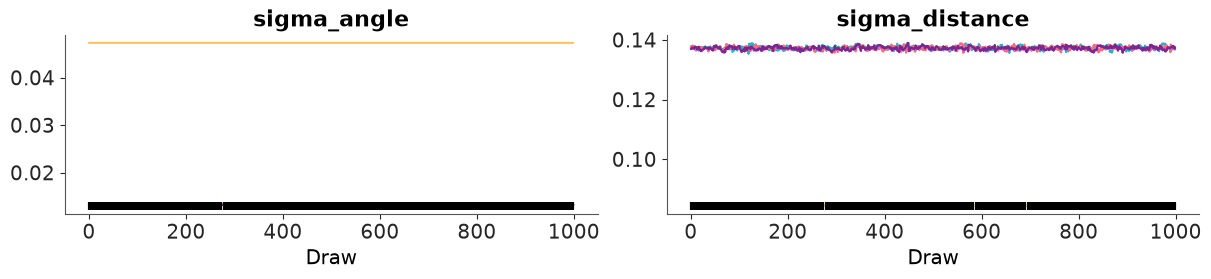

In [16]:
az.plot_trace(binomial_idata);

`r_hat` far above 1.01 and single-digit ESS: the chains disagree. This is **not** a
sampler problem to be fixed with `target_accept` or more tuning.

Look at `n`: tens of thousands of putts at short range. A Binomial likelihood with
$n \approx 50{,}000$ insists the model hit each observed rate to within a fraction of a
percentage point. No two-parameter curve can do that at all 31 distances, so the
posterior collapses into razor-thin, isolated modes, each matching a different subset of
the points. The model is *wrong in a small way* and the data are plentiful enough to notice.

The fix is to admit it: the true success rates deviate from our idealised curve by some
small amount $\sigma_y$ (greens differ, pressure differs...). Using the Normal
approximation to the Binomial for the observed rate:

$$y_i/n_i \sim \text{Normal}\!\left(p_i,\ \sqrt{p_i(1-p_i)/n_i + \sigma_y^2}\right)$$

In [17]:
with pm.Model() as final_model:
    sigma_angle = pm.HalfNormal("sigma_angle", 0.1)
    sigma_distance = pm.HalfNormal("sigma_distance", 0.5)
    sigma_y = pm.HalfNormal("sigma_y", 0.05)
    pm.Deterministic("sigma_angle_deg", sigma_angle * 180 / np.pi)

    p = p_angle(xn, sigma_angle) * p_distance(xn, sigma_distance)
    pm.Normal("rate", mu=p, sigma=pm.math.sqrt(p * (1 - p) / nn + sigma_y**2), observed=yn / nn)
    final_idata = pm.sample(random_seed=RANDOM_SEED)

az.summary(final_idata)

NUTS[nutpie]: [sigma_angle, sigma_distance, sigma_y]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle,0.017803,0.000101,0.018,0.018,1151,1588,1.00,3e-06,1.9e-06
sigma_distance,0.08011,0.00125,0.078,0.082,1193,1575,1.00,3.6e-05,2.5e-05
sigma_y,0.00308,0.00059,0.0022,0.0041,1905,2156,1.00,1.4e-05,1.1e-05
sigma_angle_deg,1.02,0.0058,1,1,1151,1588,1.00,0.00017,0.00011


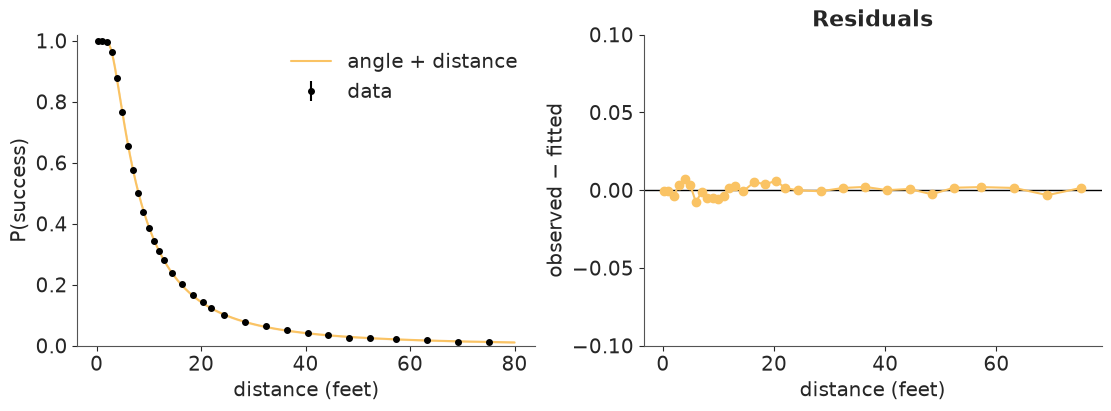

In [18]:
post = az.extract(final_idata, var_names=["sigma_angle", "sigma_distance"])
sa, sd = post["sigma_angle"].values[:, None], post["sigma_distance"].values[:, None]
final_curves = p_angle(x_grid, sa, xp=np) * p_distance(x_grid, sd, xp=np)
fitted = (p_angle(xn, sa, xp=np) * p_distance(xn, sd, xp=np)).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_data(golf_new, ax=axes[0])
plot_curve(final_curves, ax=axes[0], color="C2", label="angle + distance")
axes[0].legend()
axes[1].axhline(0, color="k", lw=1)
axes[1].plot(xn, yn / nn - fitted, "o-", color="C2")
axes[1].set(xlabel="distance (feet)", ylabel="observed − fitted", title="Residuals", ylim=(-0.1, 0.1));

In [19]:
assert h.check(
    "task5",
    sigma_angle_deg=final_idata.posterior["sigma_angle_deg"].mean(),
    sigma_distance=final_idata.posterior["sigma_distance"].mean(),
)

- PASS `sigma_angle_deg` = 1.02 is consistent with the reference solution.
- PASS `sigma_distance` = 0.08011 is consistent with the reference solution.

Clean diagnostics, residuals within about one percentage point, and three parameters a
coach can read: angular error of about **1°**, distance error of about **8%** of the putt
length, and a model-misfit term of **0.3 percentage points**.

The residuals are not pure noise, though: there is a small systematic wiggle between 3 and
12 feet (about ±0.7 percentage points). That is a lead for the next iteration, not
something to hide.

## Task 6 · Answer the business question

The product team asks: **"From what distance is a tour pro a coin flip?"**

**Deliver** the posterior distribution of $x_{50}$, the distance at which $p(x) = 0.5$,
with a point estimate and a 94% interval. Then the follow-up: a coaching intervention
claims to cut distance error $\sigma_d$ by a fifth. How many extra putts per 100 would
that sink from 30 feet?

In [20]:
fine_grid = np.linspace(1, 40, 4000)
p_draws = p_angle(fine_grid, sa, xp=np) * p_distance(fine_grid, sd, xp=np)  # (draws, grid)
x50 = fine_grid[np.argmax(p_draws < 0.5, axis=1)]  # first grid point below 0.5, per draw

print(f"x50 = {x50.mean():.2f} ft, 94% interval {np.quantile(x50, [0.03, 0.97]).round(2)}")

p30_now = p_angle(30.0, sa, xp=np) * p_distance(30.0, sd, xp=np)
p30_better = p_angle(30.0, sa, xp=np) * p_distance(30.0, 0.8 * sd, xp=np)
gain = 100 * (p30_better - p30_now).ravel()
print(f"extra putts per 100 from 30 ft: {gain.mean():.2f}, 94% interval {np.quantile(gain, [0.03, 0.97]).round(2)}")

x50 = 8.02 ft, 94% interval [7.98 8.06]
extra putts per 100 from 30 ft: 1.42, 94% interval [1.41 1.43]


In [21]:
assert h.check("task6", x50=x50.mean())

- PASS `x50` = 8.021 is consistent with the reference solution.

Any function of the parameters can be pushed through the posterior draw by draw - no delta
method, no bootstrap. And because the parameters are *mechanistic*, "what if distance
control improved by 20%?" is a question the model can answer. The logistic regression
never could.

## Going further

- The final residuals still wiggle systematically between 3 and 12 feet. Propose and test a mechanism.
- Refit the final model with the exact Binomial likelihood plus a *Beta-Binomial* or a
  logit-normal random effect per distance instead of the Normal approximation. Do the
  conclusions change?
- Fit both datasets jointly with shared physics but dataset-specific skill parameters. Did
  pros improve between the 1990s and the 2010s?

In [22]:
h.progress()

**C01**: 0/18 hints used, 6/6 checks passed.